**Uni directional**

In [1]:
# Cell 1 — Imports & GPU Check
import sys, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, GRU, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print("Python     :", sys.version[:6])
print("TensorFlow :", tf.__version__)
print("Pandas     :", pd.__version__)
print("NumPy      :", np.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ GPU available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"   → {gpu.name}")
else:
    print("\n⚠️  No GPU — using CPU (training will be slow)")

print("\n✅ All libraries loaded!")

2026-07-10 14:38:29.238254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783694309.498045      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783694309.576919      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783694310.152658      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783694310.152696      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783694310.152699      23 computation_placer.cc:177] computation placer alr

Python     : 3.12.1
TensorFlow : 2.19.0
Pandas     : 2.3.3
NumPy      : 2.0.2

✅ GPU available: 2 device(s)
   → /physical_device:GPU:0
   → /physical_device:GPU:1

✅ All libraries loaded!


In [2]:
# Cell 2 — Load MULTIPLE scenarios and combine
import pandas as pd
import os

# ── List all scenario files ───────────────────────
scenario_files = [
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/1_capture20110810.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/2_capture20110811.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/3_capture20110812.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/4_capture20110815.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/5_capture20110815-2.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/6_capture20110816.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/7_capture20110816-2.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/8_capture20110816-3.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/9_capture20110817.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/10_capture20110818.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/11_capture20110818-2.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-daa/CTU-data/12_capture20110819.binetflow',
    '/kaggle/input/datasets/mdishanth/ctu-data-set/13_capture20110815-3.binetflow',# Cell 3 — Preprocess, Balance & Map Labels (Multi-Scenario)
]

# ── Load only files that exist ────────────────────
all_dfs = []

for filepath in scenario_files:
    if os.path.exists(filepath):
        temp_df = pd.read_csv(filepath)
        scenario_name = os.path.basename(filepath)

        # Add a column to track which scenario each row came from
        temp_df['scenario'] = scenario_name

        all_dfs.append(temp_df)
        print(f"✅ Loaded {scenario_name:35} → {len(temp_df):>10,} rows")
    else:
        print(f"⚠️  Skipped {filepath} — file not found")

# ── Combine all into one DataFrame ────────────────
df = pd.concat(all_dfs, ignore_index=True)

print(f"\n{'='*50}")
print(f"📊 Total rows combined   : {len(df):,}")
print(f"📊 Total columns         : {df.shape[1]}")
print(f"📊 Scenarios loaded      : {len(all_dfs)}")
print(f"\n🏷️  Top 15 Labels across all scenarios:")
print(df['Label'].value_counts().head(15))

✅ Loaded 1_capture20110810.binetflow         →  2,824,636 rows
✅ Loaded 2_capture20110811.binetflow         →  1,808,122 rows
✅ Loaded 3_capture20110812.binetflow         →  4,710,638 rows
✅ Loaded 4_capture20110815.binetflow         →  1,121,076 rows
✅ Loaded 5_capture20110815-2.binetflow       →    129,832 rows
✅ Loaded 6_capture20110816.binetflow         →    558,919 rows
✅ Loaded 7_capture20110816-2.binetflow       →    114,077 rows
✅ Loaded 8_capture20110816-3.binetflow       →  2,954,230 rows
✅ Loaded 9_capture20110817.binetflow         →  2,087,508 rows
✅ Loaded 10_capture20110818.binetflow        →  1,309,791 rows
✅ Loaded 11_capture20110818-2.binetflow      →    107,251 rows
✅ Loaded 12_capture20110819.binetflow        →    325,471 rows
✅ Loaded 13_capture20110815-3.binetflow      →  1,925,149 rows

📊 Total rows combined   : 19,976,700
📊 Total columns         : 16
📊 Scenarios loaded      : 13

🏷️  Top 15 Labels across all scenarios:
Label
flow=To-Background-UDP-CVUT-DNS-Server

In [3]:
# Cell 3 — Preprocess, Balance & Map Labels

# ── Label mapping ─────────────────────────────────
def map_label(label):
    label = str(label).lower()
    if 'botnet' in label:
        if 'cc' in label or 'command' in label:
            return 2
        elif 'infection' in label or 'exploit' in label:
            return 1
        else:
            return 3
    return 0

df['stage']      = df['Label'].apply(map_label)
stage_name_map   = {0:'Normal', 1:'Infection', 2:'C&C', 3:'Attack'}

print("📊 Distribution per scenario:\n")
for scenario in df['scenario'].unique():
    subset = df[df['scenario'] == scenario]
    print(f"  📁 {scenario}")
    for s, c in subset['stage'].value_counts().sort_index().items():
        print(f"     Stage {s} ({stage_name_map[s]}): {c:,}")
    print()

# ── Balance each scenario separately ─────────────
balanced_parts = []
for scenario in df['scenario'].unique():
    subset = df[df['scenario'] == scenario].copy()
    parts  = []
    for stage in [0, 1, 2, 3]:
        stage_df = subset[subset['stage'] == stage]
        if len(stage_df) == 0:
            continue
        if stage == 0:
            n = min(len(stage_df), 30000)
            parts.append(stage_df.sample(n=n, random_state=42))
        elif stage in [1, 2]:
            n = min(max(len(stage_df), 3000), 8000)
            parts.append(stage_df.sample(n=n, replace=True, random_state=42))
        elif stage == 3:
            n = min(len(stage_df), 30000)
            parts.append(stage_df.sample(n=n, random_state=42))
    balanced_parts.append(pd.concat(parts))

df_bal = pd.concat(balanced_parts, ignore_index=True)
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

print("📊 Final balanced distribution:")
for s, c in df_bal['stage'].value_counts().sort_index().items():
    print(f"  Stage {s} ({stage_name_map[s]}): {c:,}")
print(f"\n✅ Total: {len(df_bal):,} rows")

# ── Add time features ─────────────────────────────
df_bal['StartTime'] = pd.to_datetime(df_bal['StartTime'], errors='coerce')
df_bal['hour']      = df_bal['StartTime'].dt.hour.fillna(0)
df_bal['minute']    = df_bal['StartTime'].dt.minute.fillna(0)

# ── Encode & normalize ────────────────────────────
features = ['Dur', 'Proto', 'TotPkts', 'TotBytes',
            'SrcBytes', 'hour', 'minute']

le = LabelEncoder()
df_bal['Proto'] = le.fit_transform(
    df_bal['Proto'].fillna('unknown').astype(str)
)
df_bal[features] = df_bal[features].fillna(0)

scaler = MinMaxScaler()
df_bal[features] = scaler.fit_transform(df_bal[features])

print(f"\n✅ Features ({len(features)}): {features}")
print("✅ Encoded and normalized!")

📊 Distribution per scenario:

  📁 1_capture20110810.binetflow
     Stage 0 (Normal): 2,783,675
     Stage 2 (C&C): 341
     Stage 3 (Attack): 40,620

  📁 2_capture20110811.binetflow
     Stage 0 (Normal): 1,787,181
     Stage 2 (C&C): 673
     Stage 3 (Attack): 20,268

  📁 3_capture20110812.binetflow
     Stage 0 (Normal): 4,683,816
     Stage 2 (C&C): 63
     Stage 3 (Attack): 26,759

  📁 4_capture20110815.binetflow
     Stage 0 (Normal): 1,118,496
     Stage 2 (C&C): 52
     Stage 3 (Attack): 2,528

  📁 5_capture20110815-2.binetflow
     Stage 0 (Normal): 128,931
     Stage 2 (C&C): 24
     Stage 3 (Attack): 877

  📁 6_capture20110816.binetflow
     Stage 0 (Normal): 554,289
     Stage 2 (C&C): 199
     Stage 3 (Attack): 4,431

  📁 7_capture20110816-2.binetflow
     Stage 0 (Normal): 114,014
     Stage 2 (C&C): 26
     Stage 3 (Attack): 37

  📁 8_capture20110816-3.binetflow
     Stage 0 (Normal): 2,948,103
     Stage 2 (C&C): 1,074
     Stage 3 (Attack): 5,053

  📁 9_capture20110817.

In [4]:
# Cell 4 — Build Sequences & Train/Test Split   PREPROCESSING
SEQ_LEN    = 30
N_FEATURES = len(features)
N_CLASSES  = 4

df_bal = df_bal.sort_values(
    ['scenario', 'SrcAddr', 'StartTime']
).reset_index(drop=True)

def create_sequences(df, features, seq_len=30):
    X, y, skipped = [], [], 0
    for (scenario, ip), group in df.groupby(['scenario', 'SrcAddr']):
        group  = group.sort_values('StartTime')
        vals   = group[features].values
        labels = group['stage'].values
        if len(vals) < seq_len + 1:
            skipped += 1
            continue
        for i in range(len(vals) - seq_len):
            X.append(vals[i:i+seq_len])
            y.append(labels[i+seq_len-1])
    print(f"⚠️  Skipped {skipped:,} IP groups (not enough flows)")
    return np.array(X, dtype=np.float32), np.array(y)

X, y = create_sequences(df_bal, features, seq_len=SEQ_LEN)
y_cat = to_categorical(y, num_classes=N_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Sequences created!")
print(f"📊 X shape   : {X.shape}")
print(f"📊 Train set : {X_train.shape[0]:,} samples")
print(f"📊 Test set  : {X_test.shape[0]:,} samples")
print(f"\n📌 Label distribution:")
for s, c in zip(*np.unique(y, return_counts=True)):
    print(f"  Stage {int(s)} ({stage_name_map[int(s)]}): {c:,}")

⚠️  Skipped 106,604 IP groups (not enough flows)

✅ Sequences created!
📊 X shape   : (463376, 30, 7)
📊 Train set : 370,700 samples
📊 Test set  : 92,676 samples

📌 Label distribution:
  Stage 0 (Normal): 235,378
  Stage 2 (C&C): 38,260
  Stage 3 (Attack): 189,738


In [5]:
# Cell 5 — Build Unidirectional LSTM & GRU Models

def build_lstm(seq_len, n_features, n_classes):
    model = Sequential([
        # Layer 1
        LSTM(128, input_shape=(seq_len, n_features),
             return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3
        LSTM(32),
        BatchNormalization(),
        Dropout(0.2),

        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64,  activation='relu'),
        Dense(n_classes, activation='softmax')
    ], name='LSTM_Model')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_gru(seq_len, n_features, n_classes):
    model = Sequential([
        # Layer 1
        GRU(128, input_shape=(seq_len, n_features),
            return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2
        GRU(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3
        GRU(32),
        BatchNormalization(),
        Dropout(0.2),

        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64,  activation='relu'),
        Dense(n_classes, activation='softmax')
    ], name='GRU_Model')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(SEQ_LEN, N_FEATURES, N_CLASSES)
gru_model  = build_gru(SEQ_LEN,  N_FEATURES, N_CLASSES)

print("LSTM Architecture:")
lstm_model.summary()
print("\nGRU Architecture:")
gru_model.summary()

I0000 00:00:1783694537.448512      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783694537.454379      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Architecture:


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,092 (566.77 KB)

...

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,900 (441.02 KB)

 Trainable params: 112,452 (439.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
# Cell 6 — Train LSTM & GRU

def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            f'/kaggle/working/{model_name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

# ── Train LSTM ────────────────────────────────────
print("⏳ Training LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=256,
    callbacks=get_callbacks('lstm'),
    verbose=1
)
print(f"\n✅ LSTM done!")
print(f"   Epochs ran       : {len(lstm_history.history['accuracy'])}")
print(f"   Best val accuracy: {max(lstm_history.history['val_accuracy']):.4f}")

# ── Train GRU ─────────────────────────────────────
print("\n⏳ Training GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=256,
    callbacks=get_callbacks('gru'),
    verbose=1
)
print(f"\n✅ GRU done!")
print(f"   Epochs ran       : {len(gru_history.history['accuracy'])}")
print(f"   Best val accuracy: {max(gru_history.history['val_accuracy']):.4f}")

⏳ Training LSTM...
Epoch 1/60


I0000 00:00:1783694544.590522      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


1304/1304 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.7741 - loss: 0.5599 - val_accuracy: 0.8014 - val_loss: 0.5623 - learning_rate: 0.0010
Epoch 2/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8619 - loss: 0.3558 - val_accuracy: 0.7971 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 3/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.8763 - loss: 0.3139 - val_accuracy: 0.7943 - val_loss: 0.5094 - learning_rate: 0.0010
Epoch 4/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8894 - loss: 0.2825 - val_accuracy: 0.8771 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 5/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8988 - loss: 0.2584 - val_accuracy: 0.8755 - val_loss: 0.3459 - learning_rate: 0.0010
Epoch 6/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9108 - loss: 0.2287 - val_accuracy: 0.7595 - val_loss: 0.6465 - learning_rate: 0.0010
Epoch 7/60
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9215 

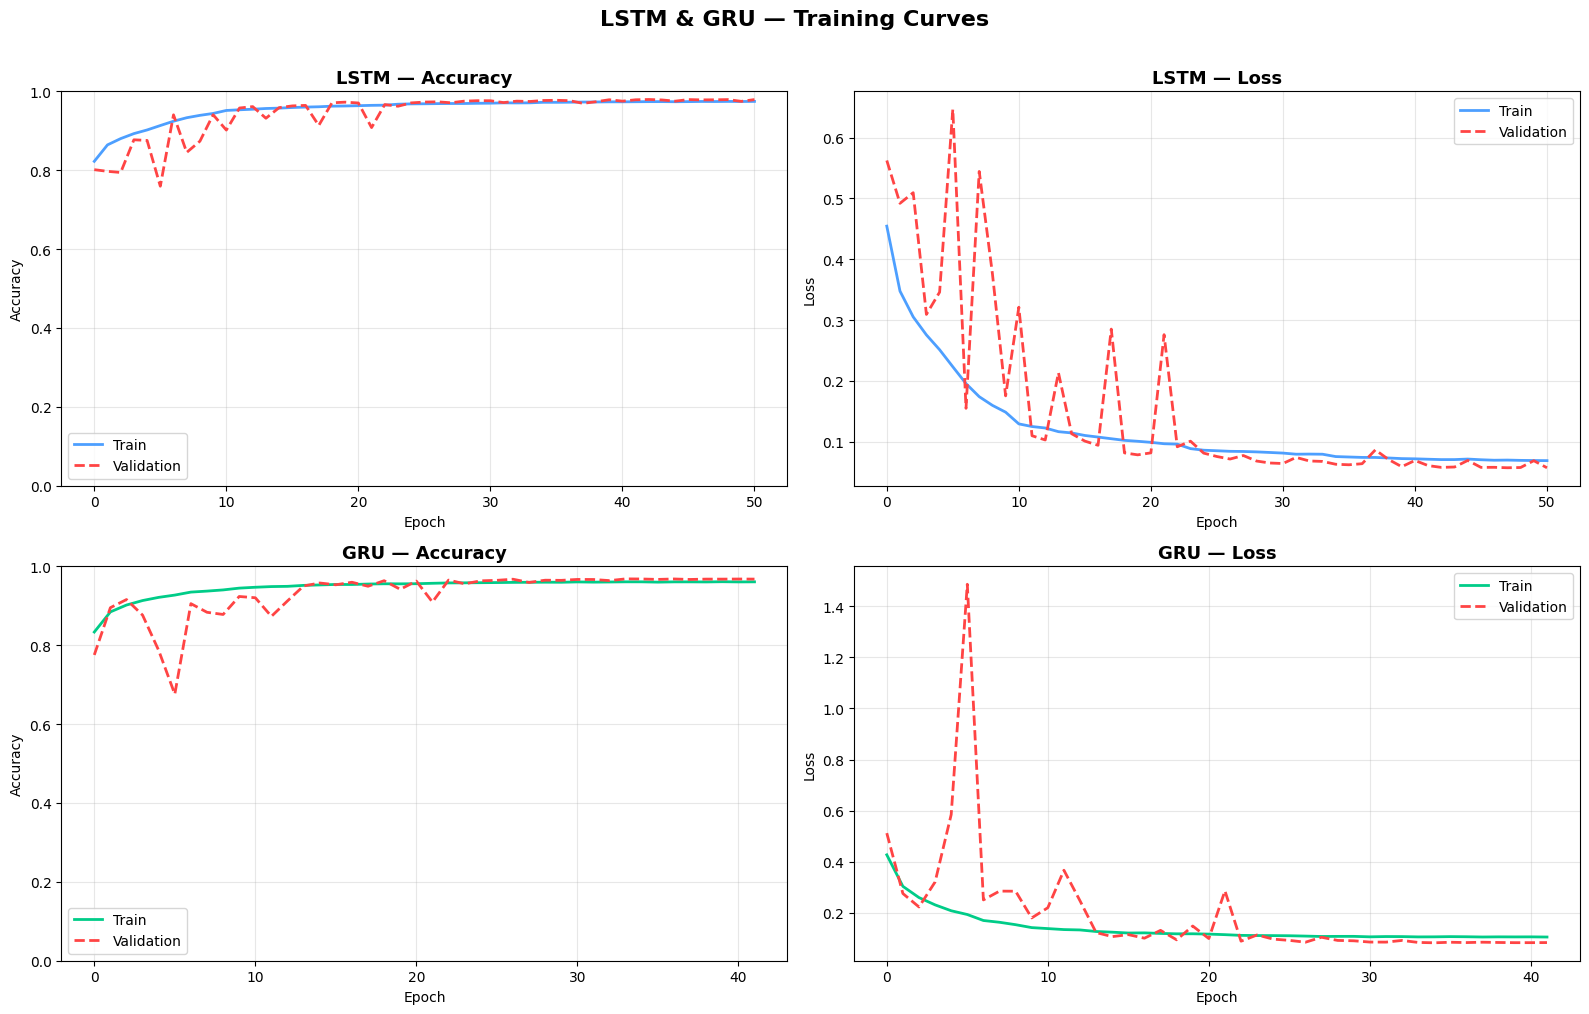

✅ Training curves saved!


In [7]:
# Cell 7 — Plot Training Curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (history, name, color) in enumerate([
    (lstm_history, 'LSTM', '#4d9fff'),
    (gru_history,  'GRU',  '#00cc88')
]):
    axes[idx, 0].plot(history.history['accuracy'],
                      color=color, linewidth=2, label='Train')
    axes[idx, 0].plot(history.history['val_accuracy'],
                      color='#ff4444', linewidth=2,
                      linestyle='--', label='Validation')
    axes[idx, 0].set_title(f'{name} — Accuracy',
                           fontsize=13, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Accuracy')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_ylim(0, 1)

    axes[idx, 1].plot(history.history['loss'],
                      color=color, linewidth=2, label='Train')
    axes[idx, 1].plot(history.history['val_loss'],
                      color='#ff4444', linewidth=2,
                      linestyle='--', label='Validation')
    axes[idx, 1].set_title(f'{name} — Loss',
                           fontsize=13, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Loss')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('LSTM & GRU — Training Curves',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Training curves saved!")

       LSTM — Classification Report
              precision    recall  f1-score   support

      Normal     0.9896    0.9938    0.9916     47076
         C&C     0.9331    0.8643    0.8974      7652
      Attack     0.9731    0.9824    0.9777     37948

    accuracy                         0.9784     92676
   macro avg     0.9653    0.9468    0.9556     92676
weighted avg     0.9782    0.9784    0.9782     92676

       GRU — Classification Report
              precision    recall  f1-score   support

      Normal     0.9867    0.9863    0.9865     47076
         C&C     0.9060    0.8291    0.8658      7652
      Attack     0.9590    0.9760    0.9675     37948

    accuracy                         0.9691     92676
   macro avg     0.9506    0.9305    0.9399     92676
weighted avg     0.9687    0.9691    0.9687     92676



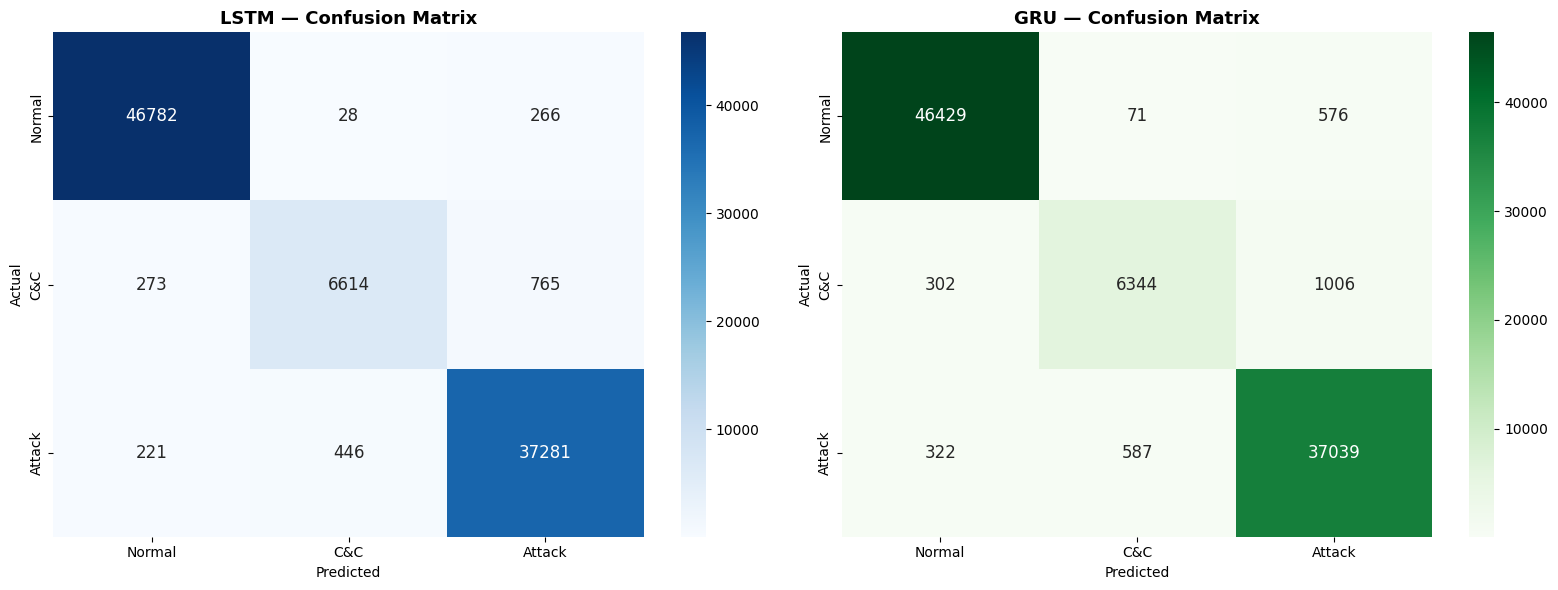

✅ Confusion matrices saved!


In [8]:
# Cell 8 — Evaluate LSTM & GRU

stage_names = ['Normal', 'Infection', 'C&C', 'Attack']

lstm_pred = np.argmax(lstm_model.predict(X_test, verbose=0), axis=1)
gru_pred  = np.argmax(gru_model.predict(X_test,  verbose=0), axis=1)
y_true    = np.argmax(y_test, axis=1)

existing     = sorted(np.unique(y_true).tolist())
exist_names  = [stage_names[i] for i in existing]

for pred, name in [(lstm_pred, 'LSTM'), (gru_pred, 'GRU')]:
    print(f"{'='*58}")
    print(f"       {name} — Classification Report")
    print(f"{'='*58}")
    print(classification_report(
        y_true, pred,
        labels=existing,
        target_names=exist_names,
        digits=4
    ))

# ── Confusion matrices ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, pred, name, cmap in [
    (ax1, lstm_pred, 'LSTM', 'Blues'),
    (ax2, gru_pred,  'GRU',  'Greens')
]:
    cm = confusion_matrix(y_true, pred, labels=existing)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=exist_names,
                yticklabels=exist_names, ax=ax,
                annot_kws={'size': 12})
    ax.set_title(f'{name} — Confusion Matrix',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

In [9]:
# Cell 9 — Detection Delay Analysis (Fixed)

# ── Prepare data ──────────────────────────────────
df_delay = df.copy()
df_delay['StartTime'] = pd.to_datetime(
    df_delay['StartTime'], errors='coerce'
)
df_delay = df_delay.dropna(subset=['StartTime'])
df_delay['hour']   = df_delay['StartTime'].dt.hour.fillna(0)
df_delay['minute'] = df_delay['StartTime'].dt.minute.fillna(0)

# ── Safe protocol encoding ────────────────────────
known_classes = list(le.classes_)
df_delay['Proto'] = df_delay['Proto'].fillna('unknown').astype(str)
df_delay['Proto'] = df_delay['Proto'].apply(
    lambda x: x if x in known_classes else known_classes[0]
)
df_delay['Proto']  = le.transform(df_delay['Proto'])
df_delay[features] = df_delay[features].fillna(0)

# ── Safe scaler transform ─────────────────────────
try:
    df_delay[features] = scaler.transform(df_delay[features])
except Exception as e:
    print(f"⚠️  Scaler error: {e} — refitting on delay data")
    df_delay[features] = scaler.fit_transform(df_delay[features])

df_delay['stage'] = df_delay['Label'].apply(map_label)
df_delay = df_delay.sort_values(
    ['SrcAddr', 'StartTime']
).reset_index(drop=True)

# ── Find all botnet IPs ───────────────────────────
print("🔍 Searching for botnet IPs...\n")
botnet_ips = []

for ip, group in df_delay.groupby('SrcAddr'):
    has_attack  = any(group['stage'] > 0)
    has_enough  = len(group) >= SEQ_LEN + 10
    if has_attack and has_enough:
        botnet_ips.append(ip)
        stage_dist = group['stage'].value_counts().sort_index().to_dict()
        print(f"  ✅ IP: {ip:20} | Flows: {len(group):>8,} | "
              f"Stages: {stage_dist}")

if not botnet_ips:
    print("⚠️  No botnet IPs found with enough flows!")
    print("   Lowering minimum flow threshold and retrying...")
    for ip, group in df_delay.groupby('SrcAddr'):
        if any(group['stage'] > 0):
            botnet_ips.append(ip)
            print(f"  ✅ IP: {ip} | Flows: {len(group):,}")

print(f"\n📌 Total botnet IPs found: {len(botnet_ips)}")

# ── Fast batch simulation ─────────────────────────
def simulate_fast(model, df_ip, features, seq_len, model_name):
    vals   = df_ip[features].values.astype(np.float32)
    stages = df_ip['stage'].values
    n      = len(vals)

    if n < seq_len + 1:
        print(f"    ⚠️  {model_name}: only {n} flows, need {seq_len+1}")
        return None, None, [], None

    # Build all windows at once
    X_win = np.array([
        vals[i:i+seq_len] for i in range(n - seq_len)
    ])
    y_seq = np.array([
        stages[i+seq_len-1] for i in range(n - seq_len)
    ])

    # Batch predict
    preds      = np.argmax(
        model.predict(X_win, batch_size=2048, verbose=0), axis=1
    )
    alerts     = np.where(preds > 0)[0].tolist()
    true_start = next((i for i, s in enumerate(y_seq) if s > 0), None)
    first_alert= alerts[0] if alerts else None

    if true_start is None:
        print(f"    ⚠️  {model_name}: no attack flows found in sequence")
        return preds, y_seq, alerts, None

    delay = (first_alert - true_start
             if first_alert is not None else None)

    status = f"delay={delay} flows" if delay is not None else "not detected"
    print(f"    {model_name:6}: attack@#{true_start} | "
          f"alert@#{first_alert} | {status}")

    return preds, y_seq, alerts, true_start

# ── Run simulation for each botnet IP ────────────
all_lstm_delays = []
all_gru_delays  = []

for ip in botnet_ips[:5]:
    df_ip = df_delay[
        df_delay['SrcAddr'] == ip
    ].reset_index(drop=True)

    print(f"\n🔍 IP: {ip} ({len(df_ip):,} flows)")

    _, _, a1, s1 = simulate_fast(
        lstm_model, df_ip, features, SEQ_LEN, "LSTM"
    )
    _, _, a2, s2 = simulate_fast(
        gru_model,  df_ip, features, SEQ_LEN, "GRU"
    )

    if a1 and s1 is not None:
        d = a1[0] - s1
        if d >= 0:
            all_lstm_delays.append(d)

    if a2 and s2 is not None:
        d = a2[0] - s2
        if d >= 0:
            all_gru_delays.append(d)

# ── Delay summary ─────────────────────────────────
print(f"\n{'='*55}")
print("         DETECTION DELAY SUMMARY")
print(f"{'='*55}")
if all_lstm_delays:
    print(f"  LSTM → Avg: {np.mean(all_lstm_delays):.1f} | "
          f"Min: {np.min(all_lstm_delays)} | "
          f"Max: {np.max(all_lstm_delays)} flows | "
          f"Hosts: {len(all_lstm_delays)}")
else:
    print("  LSTM → No delays recorded")

if all_gru_delays:
    print(f"  GRU  → Avg: {np.mean(all_gru_delays):.1f} | "
          f"Min: {np.min(all_gru_delays)} | "
          f"Max: {np.max(all_gru_delays)} flows | "
          f"Hosts: {len(all_gru_delays)}")
else:
    print("  GRU  → No delays recorded")
print(f"{'='*55}")
print("✅ Cell 9 complete!")

🔍 Searching for botnet IPs...

  ✅ IP: 147.32.84.165        | Flows:  180,298 | Stages: {0: 4, 2: 3228, 3: 177066}
  ✅ IP: 147.32.84.191        | Flows:   34,002 | Stages: {0: 2, 2: 334, 3: 33666}
  ✅ IP: 147.32.84.192        | Flows:   31,280 | Stages: {0: 1, 2: 308, 3: 30971}
  ✅ IP: 147.32.84.193        | Flows:   27,971 | Stages: {0: 1, 2: 308, 3: 27662}
  ✅ IP: 147.32.84.204        | Flows:   29,944 | Stages: {0: 2, 2: 279, 3: 29663}
  ✅ IP: 147.32.84.205        | Flows:   29,411 | Stages: {0: 2, 2: 301, 3: 29108}
  ✅ IP: 147.32.84.206        | Flows:   29,841 | Stages: {0: 1, 2: 265, 3: 29575}
  ✅ IP: 147.32.84.207        | Flows:   26,583 | Stages: {0: 3, 2: 281, 3: 26299}
  ✅ IP: 147.32.84.208        | Flows:   29,028 | Stages: {0: 1, 2: 255, 3: 28772}
  ✅ IP: 147.32.84.209        | Flows:   26,278 | Stages: {0: 8, 2: 374, 3: 25896}
  ✅ IP: 38.229.70.20         | Flows:       70 | Stages: {0: 7, 2: 63}

📌 Total botnet IPs found: 11

🔍 IP: 147.32.84.165 (180,298 flows)
    LSTM 

⏳ Training Random Forest...
✅ RF done! Accuracy: 0.9770 | F1: 0.9770

              FINAL PROJECT SUMMARY
  Model                          Accuracy         F1        Delay   Epochs
  --------------------------------------------------------------
  LSTM (sequence)                  0.9784     0.9782    2.8 flows       51
  GRU  (sequence)                  0.9691     0.9687    8.6 flows       42
  Random Forest (single)           0.9770     0.9770          N/A      N/A
  --------------------------------------------------------------

  🏆 Best Accuracy   : LSTM
  ⚡ Fastest Detection: LSTM
  🔁 Most Efficient   : GRU (fewer epochs)
  🧠 RF cannot model  : temporal attack progression


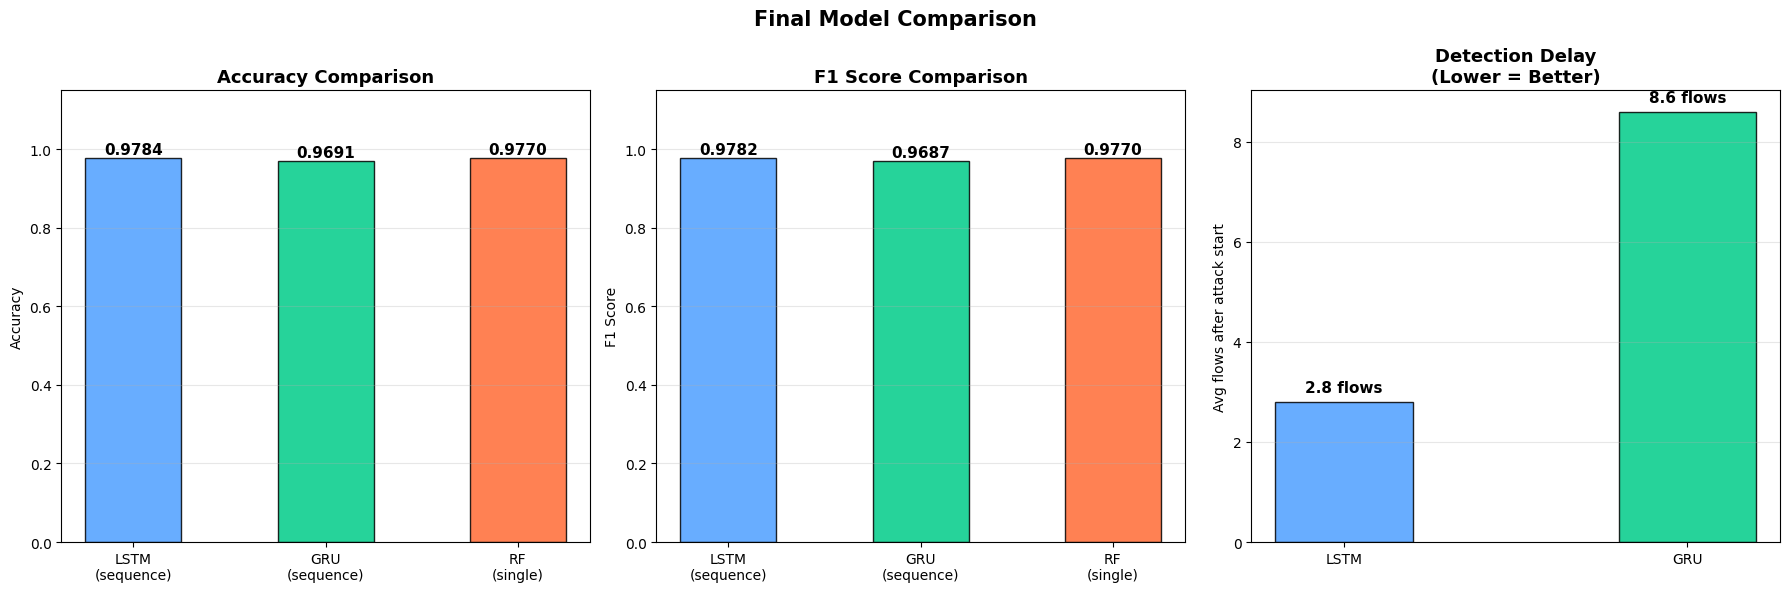

In [10]:
# Cell 10 — Final Comparison & Summary (Fixed)

# ── Random Forest baseline ────────────────────────
X_single = X[:, -1, :]
y_single = np.argmax(y_cat, axis=1)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_single, y_single,
    test_size=0.2, random_state=42, stratify=y_single
)
print("⏳ Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_te)
rf_acc  = accuracy_score(y_te, rf_pred)
rf_f1   = f1_score(y_te, rf_pred, average='weighted')
print(f"✅ RF done! Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f}")

# ── Check all required variables exist ───────────
# Safety defaults in case Cell 8 or 9 had issues
try:
    _ = y_true
except NameError:
    y_true    = np.argmax(y_test, axis=1)
    lstm_pred = np.argmax(lstm_model.predict(X_test, verbose=0), axis=1)
    gru_pred  = np.argmax(gru_model.predict(X_test,  verbose=0), axis=1)
    print("⚠️  Regenerated predictions from models")

# ── All metrics ───────────────────────────────────
lstm_acc = accuracy_score(y_true, lstm_pred)
gru_acc  = accuracy_score(y_true, gru_pred)
lstm_f1  = f1_score(y_true, lstm_pred, average='weighted')
gru_f1   = f1_score(y_true, gru_pred,  average='weighted')

lstm_delay_val = np.mean(all_lstm_delays) if all_lstm_delays else None
gru_delay_val  = np.mean(all_gru_delays)  if all_gru_delays  else None
lstm_delay_str = f"{lstm_delay_val:.1f} flows" if lstm_delay_val is not None else "N/A"
gru_delay_str  = f"{gru_delay_val:.1f} flows"  if gru_delay_val  is not None else "N/A"

lstm_epochs = len(lstm_history.history['accuracy'])
gru_epochs  = len(gru_history.history['accuracy'])

# ── Summary table ─────────────────────────────────
print(f"\n{'='*68}")
print("              FINAL PROJECT SUMMARY")
print(f"{'='*68}")
print(f"  {'Model':<28} {'Accuracy':>10} {'F1':>10} "
      f"{'Delay':>12} {'Epochs':>8}")
print(f"  {'-'*62}")
print(f"  {'LSTM (sequence)':<28} {lstm_acc:>10.4f} "
      f"{lstm_f1:>10.4f} {lstm_delay_str:>12} {lstm_epochs:>8}")
print(f"  {'GRU  (sequence)':<28} {gru_acc:>10.4f} "
      f"{gru_f1:>10.4f} {gru_delay_str:>12} {gru_epochs:>8}")
print(f"  {'Random Forest (single)':<28} {rf_acc:>10.4f} "
      f"{rf_f1:>10.4f} {'N/A':>12} {'N/A':>8}")
print(f"  {'-'*62}")

best = 'LSTM' if lstm_acc >= gru_acc else 'GRU'
effi = 'GRU'  if gru_epochs <= lstm_epochs else 'LSTM'

if lstm_delay_val and gru_delay_val:
    fast = 'LSTM' if lstm_delay_val <= gru_delay_val else 'GRU'
elif lstm_delay_val:
    fast = 'LSTM'
elif gru_delay_val:
    fast = 'GRU'
else:
    fast = 'N/A'

print(f"\n  🏆 Best Accuracy   : {best}")
print(f"  ⚡ Fastest Detection: {fast}")
print(f"  🔁 Most Efficient   : {effi} (fewer epochs)")
print(f"  🧠 RF cannot model  : temporal attack progression")
print(f"{'='*68}")

# ── Final charts ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models     = ['LSTM\n(sequence)', 'GRU\n(sequence)', 'RF\n(single)']
accuracies = [lstm_acc, gru_acc, rf_acc]
f1_scores  = [lstm_f1,  gru_f1,  rf_f1]
colors     = ['#4d9fff', '#00cc88', '#ff6b35']

# Accuracy chart
for ax, values, title, ylabel in [
    (axes[0], accuracies, 'Accuracy Comparison', 'Accuracy'),
    (axes[1], f1_scores,  'F1 Score Comparison', 'F1 Score')
]:
    bars = ax.bar(models, values, color=colors,
                  edgecolor='black', alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.4f}', ha='center',
                fontsize=11, fontweight='bold')

# Delay chart — only show models with valid delay
delay_models = []
delay_vals   = []
delay_colors_used = []
color_map = {'LSTM': '#4d9fff', 'GRU': '#00cc88'}

for name, val in [('LSTM', lstm_delay_val), ('GRU', gru_delay_val)]:
    if val is not None:
        delay_models.append(name)
        delay_vals.append(val)
        delay_colors_used.append(color_map[name])

if delay_vals:
    bars = axes[2].bar(delay_models, delay_vals,
                       color=delay_colors_used,
                       edgecolor='black', alpha=0.85, width=0.4)
    axes[2].set_title('Detection Delay\n(Lower = Better)',
                      fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Avg flows after attack start')
    axes[2].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, delay_vals):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.2,
                     f'{val:.1f} flows', ha='center',
                     fontsize=11, fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'No delay data available',
                 ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Detection Delay', fontsize=13, fontweight='bold')

plt.suptitle('Final Model Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

